# Assignment D - Questions 7, 8, and 9

*DTU - Energy Islands Controversy Analysis*

This notebook generates the visualizations needed for questions 7, 8, and 9 of Assignment D.

## Settings

In [2]:
# SETTINGS
settings = {}

settings['statements_dataset'] = '../../data/Actor statement dataset.csv'

settings['year_first'] = 2016
settings['year_last'] = 2025
settings['plot_width']  = 12
settings['plot_height'] =  6

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load dataset
df = pd.read_csv(settings['statements_dataset'], dtype=str)
df = df.fillna('')

# Set 'Year' column to int
df['Year'] = df['Year'].replace('', pd.NA)
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype(pd.Int64Dtype())

# Set 'X', 'Y' and 'Size' columns to float
df['X'] = pd.to_numeric(df['X'], errors='coerce')
df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

print(f'Data loaded: {len(df)} statements')

Data loaded: 6061 statements


---
# Question 7: Statements MENTIONING the Danish Energy Agency

Visualize the evolution of the proportion of statements mentioning the agency so that we can identify when the peak is reached.

In [4]:
# Query: Statements that MENTION the Danish Energy Agency
condition_q7 = df['Statement'].str.contains('Energy Agency', case=False, na=False)
title_q7 = "Statements mentioning the Danish Energy Agency"

print(f"Total statements matching: {condition_q7.sum()}")

Total statements matching: 207


Peak reached in October 2025 at 50.0%
Figure saved as 'Q7_Timeline_Mentions.png'


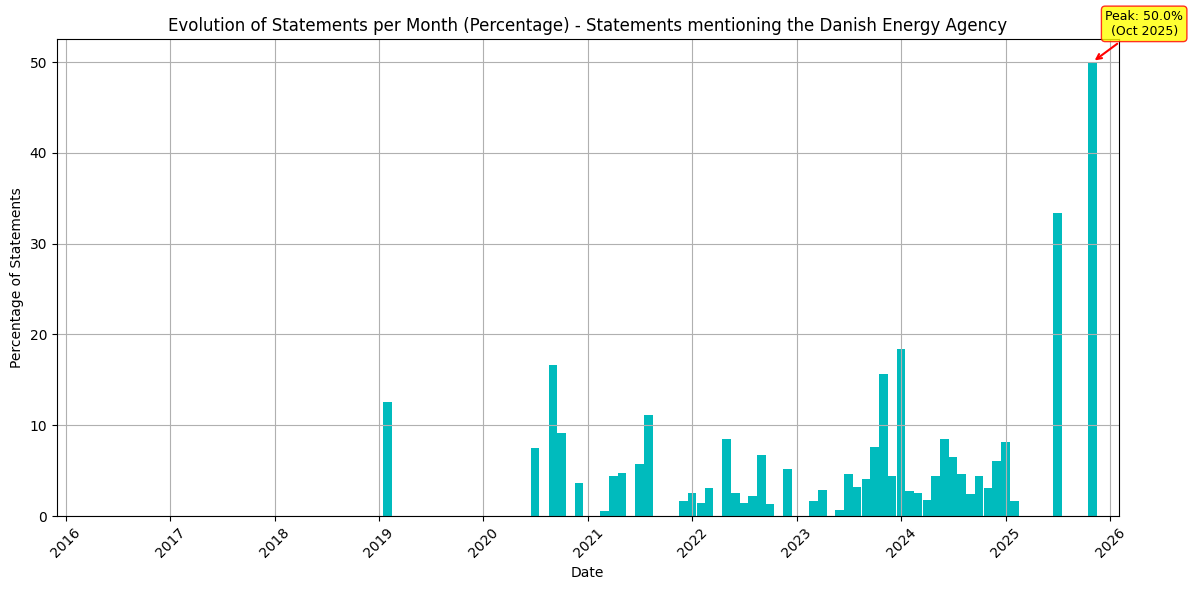

In [5]:
# Timeline visualization for Q7 (percentage, with annotation)
df_ = df.copy()
df_['filtered'] = condition_q7

# Remove rows where Year is out of range
df_ = df_[df_['Year'] >= settings['year_first']]
df_ = df_[df_['Year'] <= settings['year_last']]

# Convert 'Date of publication' to datetime
df_['Date of publication'] = pd.to_datetime(df_['Date of publication'], format='%Y-%m-%d', errors='coerce')
df_ = df_.dropna(subset=['Date of publication'])

# Group by month and filter status
monthly_statements = df_.groupby([pd.Grouper(key='Date of publication', freq='ME'), 'filtered'])['filtered'].count().unstack(fill_value=0)

# Calculate percentages
monthly_statements_percentage = monthly_statements.div(monthly_statements.sum(axis=1), axis=0) * 100

# Find the peak
if True in monthly_statements_percentage.columns:
    peak_month = monthly_statements_percentage[True].idxmax()
    peak_value = monthly_statements_percentage[True].max()
    print(f"Peak reached in {peak_month.strftime('%B %Y')} at {peak_value:.1f}%")

# Create the bar chart
plt.figure(figsize=(settings['plot_width'], settings['plot_height']))
plt.xlim(pd.to_datetime(f'{settings["year_first"]-1}-12-01'), pd.to_datetime(f'{settings["year_last"]+1}-01-31'))

try:
    plt.bar(monthly_statements_percentage.index, monthly_statements_percentage[True], width=30, color='#00BBBD')
except:
    pass

# Add peak annotation
if True in monthly_statements_percentage.columns:
    plt.annotate(
        f'Peak: {peak_value:.1f}%\n({peak_month.strftime("%b %Y")})',
        xy=(peak_month, peak_value),
        xytext=(peak_month + pd.DateOffset(months=6), peak_value + 3),
        ha='center', fontsize=9,
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', edgecolor='red', alpha=0.8)
    )

plt.xlabel('Date')
plt.ylabel('Percentage of Statements')
plt.title('Evolution of Statements per Month (Percentage) - ' + title_q7)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Save
filename = 'Q7_Timeline_Mentions.png'
plt.savefig(filename, dpi=300)
print(f"Figure saved as '{filename}'")

plt.show()

---
# Question 8: Statements AUTHORED BY the Danish Energy Agency

Visualize the evolution of the proportion of statements authored by the agency so that we can identify when the peak is reached.

In [ ]:
# Query: Statements AUTHORED BY the Danish Energy Agency
condition_q8 = (
    (df['Actor'] == 'Danish Energy Agency') |
    (df['Representative of'] == 'The Danish Energy Agency')
)
title_q8 = "Statements authored by the Danish Energy Agency"

print(f"Total statements matching: {condition_q8.sum()}")

In [ ]:
# Timeline visualization for Q8 (percentage, with annotation)
df_ = df.copy()
df_['filtered'] = condition_q8

# Remove rows where Year is out of range
df_ = df_[df_['Year'] >= settings['year_first']]
df_ = df_[df_['Year'] <= settings['year_last']]

# Convert 'Date of publication' to datetime
df_['Date of publication'] = pd.to_datetime(df_['Date of publication'], format='%Y-%m-%d', errors='coerce')
df_ = df_.dropna(subset=['Date of publication'])

# Group by month and filter status
monthly_statements = df_.groupby([pd.Grouper(key='Date of publication', freq='ME'), 'filtered'])['filtered'].count().unstack(fill_value=0)

# Calculate percentages
monthly_statements_percentage = monthly_statements.div(monthly_statements.sum(axis=1), axis=0) * 100

# Find the peak
if True in monthly_statements_percentage.columns:
    peak_month = monthly_statements_percentage[True].idxmax()
    peak_value = monthly_statements_percentage[True].max()
    print(f"Peak reached in {peak_month.strftime('%B %Y')} at {peak_value:.1f}%")

# Create the bar chart
plt.figure(figsize=(settings['plot_width'], settings['plot_height']))
plt.xlim(pd.to_datetime(f'{settings["year_first"]-1}-12-01'), pd.to_datetime(f'{settings["year_last"]+1}-01-31'))

try:
    plt.bar(monthly_statements_percentage.index, monthly_statements_percentage[True], width=30, color='#00BBBD')
except:
    pass

# Add peak annotation
if True in monthly_statements_percentage.columns:
    plt.annotate(
        f'Peak: {peak_value:.1f}%\n({peak_month.strftime("%b %Y")})',
        xy=(peak_month, peak_value),
        xytext=(peak_month + pd.DateOffset(months=6), peak_value + 3),
        ha='center', fontsize=9,
        arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', edgecolor='red', alpha=0.8)
    )

plt.xlabel('Date')
plt.ylabel('Percentage of Statements')
plt.title('Evolution of Statements per Month (Percentage) - ' + title_q8)
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# Save
filename = 'Q8_Timeline_Authored.png'
plt.savefig(filename, dpi=300)
print(f"Figure saved as '{filename}'")

plt.show()

---
# Question 9: Source Types for Kraka Economics mentioning "Energy Agency"

There are 15 statements by Kraka Economics mentioning "Energy Agency". What type(s) of sources do they come from?

In [ ]:
# Query: Kraka Economics statements mentioning "Energy Agency"
condition_q9 = (
    (df['Actor'] == 'Kraka Economics') &
    (df['Statement'].str.contains('Energy Agency', case=False, na=False))
)
title_q9 = "Kraka Economics statements mentioning Energy Agency"

print(f"Total statements matching: {condition_q9.sum()}")
print(f"\nSource types breakdown:")
print(df[condition_q9]['Source type'].value_counts())

In [ ]:
# Bar chart visualization for Q9 (absolute values with counts)
attribute = 'Source type'

df_ = df.copy()
df_['filtered'] = condition_q9

# Calculate value counts for filtered statements
source_counts = df_[df_['filtered'] == True][attribute].value_counts()

# Create the bar chart
plt.figure(figsize=(settings['plot_width'], settings['plot_height']))

# Plot horizontal bars
plt.barh(source_counts.index, source_counts.values, color='#00bbbd')

# Display counts on bars
for i, v in enumerate(source_counts.values):
    plt.text(v + 0.1, i, f' {v}', va='center', color='black', fontweight='bold')

plt.xlabel('Count')
plt.ylabel(attribute)
plt.title(f'Distribution by {attribute} - {title_q9}')
plt.gca().invert_yaxis()
plt.tight_layout()

# Save
filename = 'Q9_Source_Types.png'
plt.savefig(filename, dpi=300)
print(f"Figure saved as '{filename}'")

plt.show()

---
## Summary

The three visualizations have been saved as:
- `Q7_Timeline_Mentions.png` - Timeline of statements mentioning the Danish Energy Agency
- `Q8_Timeline_Authored.png` - Timeline of statements authored by the Danish Energy Agency  
- `Q9_Source_Types.png` - Source types for Kraka Economics statements

Use these screenshots for your assignment report.